In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk

nltk.download('punkt')
nltk.download('stopwords')

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shwet\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shwet\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
df = pd.read_csv(
    r"D:\bits course\assignment 5\customer_support_text_classification.csv"
)


In [5]:
print("\nFIRST 5 RECORDS\n")

print(df.head())


FIRST 5 RECORDS

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


In [6]:
print("\nDATASET SHAPE\n")

print(df.shape)



DATASET SHAPE

(1500, 6)


In [7]:
print("\nDATASET INFORMATION\n")

print(df.info())


DATASET INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB
None


In [8]:
print("\nTARGET LABELS\n")

print(df['sentiment_label'].unique())

# CLASS DISTRIBUTION

print("\nCLASS DISTRIBUTION\n")

print(df['sentiment_label'].value_counts())


TARGET LABELS

['neutral' 'positive' 'negative']

CLASS DISTRIBUTION

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


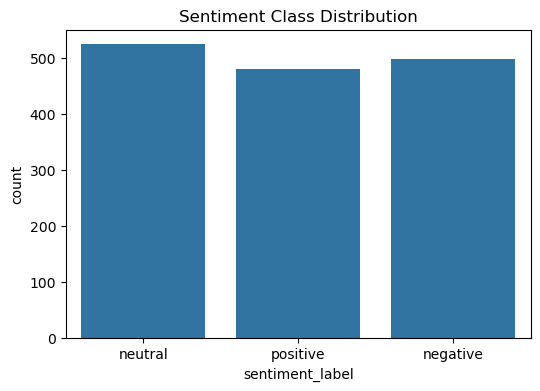

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment_label',
    data=df
)

plt.title("Sentiment Class Distribution")

plt.show()


In [10]:
print("\nSAMPLE CUSTOMER MESSAGES\n")

for i in range(5):

    print(df['customer_message'][i])

    print()


SAMPLE CUSTOMER MESSAGES

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

I need information about the payment process.

The refund process was fast and convenient. I appreciate the quick response.

My refund is still pending and this experience is frustrating. My ticket number is 33927.

Please tell me how to update my account details.



In [11]:
df['text_length'] = df['customer_message'].apply(len)

print("\nAVERAGE TEXT LENGTH\n")

print(df['text_length'].mean())


AVERAGE TEXT LENGTH

72.75666666666666


In [12]:
print("====================================================")
print("TASK 2 : TEXT PREPROCESSING")
print("====================================================")

stop_words = set(stopwords.words('english'))

TASK 2 : TEXT PREPROCESSING


In [15]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shwet\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shwet\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shwet\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
def clean_text(text):
      # LOWERCASE

    text = text.lower()

    # REMOVE SPECIAL CHARACTERS

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # TOKENIZATION

    words = word_tokenize(text)

    # REMOVE STOPWORDS

    words = [

        word for word in words

        if word not in stop_words
    ]

    # JOIN WORDS

    text = " ".join(words)

    return text

# APPLY CLEANING

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# DISPLAY CLEANED TEXT

print("\nCLEANED TEXT SAMPLE\n")

print(df[['customer_message', 'cleaned_text']].head())


CLEANED TEXT SAMPLE

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


In [18]:
print("====================================================")
print("TASK 3 : TEXT VECTORIZATION")
print("====================================================")

print("""

WHY TEXT MUST BE CONVERTED INTO VECTORS?

Machine learning models cannot understand raw text.

Models only understand numerical values.

Therefore:
- words
- sentences
- documents

must be converted into numerical vectors.

In this project we use:
TF-IDF Vectorization

""")

TASK 3 : TEXT VECTORIZATION


WHY TEXT MUST BE CONVERTED INTO VECTORS?

Machine learning models cannot understand raw text.

Models only understand numerical values.

Therefore:
- words
- sentences
- documents

must be converted into numerical vectors.

In this project we use:
TF-IDF Vectorization




In [19]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['sentiment_label']

print("\nTF-IDF FEATURE SHAPE\n")

print(X.shape)


TF-IDF FEATURE SHAPE

(1500, 146)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


In [22]:
print("====================================================")
print("TASK 4 : BASELINE MODEL")
print("====================================================")

print("""

BASELINE MODEL:
Logistic Regression with TF-IDF

""")

TASK 4 : BASELINE MODEL


BASELINE MODEL:
Logistic Regression with TF-IDF




In [23]:

model = LogisticRegression()

model.fit(X_train, y_train)

# PREDICTIONS

y_pred = model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY\n")

print(accuracy)



MODEL ACCURACY

1.0


In [25]:
print("\nCLASSIFICATION REPORT\n")

print(

    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



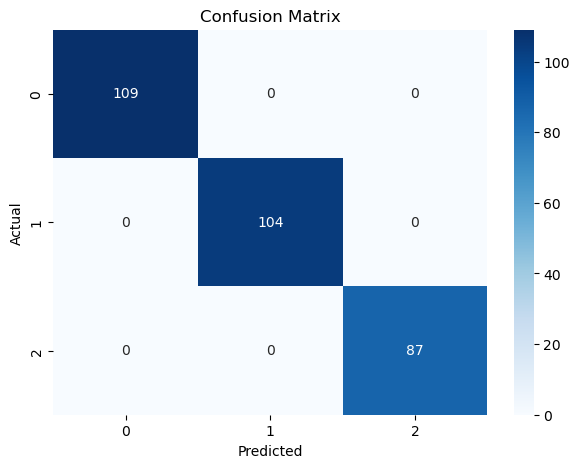

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [27]:
evaluation_df = pd.DataFrame({

    "Metric": [
        "Accuracy"
    ],

    "Value": [
        accuracy
    ]
})

evaluation_df.to_csv(
    "model_evaluation.csv",
    index=False
)

print("\nEvaluation CSV saved successfully.")


Evaluation CSV saved successfully.


In [28]:
print("====================================================")
print("SAMPLE PREDICTIONS")
print("====================================================")

sample_predictions = pd.DataFrame({

    "Actual": y_test.values[:10],

    "Predicted": y_pred[:10]
})

print(sample_predictions)


SAMPLE PREDICTIONS
     Actual Predicted
0   neutral   neutral
1  positive  positive
2   neutral   neutral
3  negative  negative
4  negative  negative
5  negative  negative
6  negative  negative
7   neutral   neutral
8  negative  negative
9  negative  negative


In [29]:
with open("sample_predictions.txt", "w") as f:

    f.write(sample_predictions.to_string())

print("\nSample predictions saved successfully.")


Sample predictions saved successfully.


In [30]:

print("====================================================")
print("TASK 5 : SEQUENCE MODEL")
print("====================================================")

print("""

LSTM SEQUENCE MODEL ARCHITECTURE

1. Input Sequence
2. Embedding Layer
3. LSTM Layer
4. Dense Layer
5. Output Layer

""")

TASK 5 : SEQUENCE MODEL


LSTM SEQUENCE MODEL ARCHITECTURE

1. Input Sequence
2. Embedding Layer
3. LSTM Layer
4. Dense Layer
5. Output Layer




In [31]:

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(
    df['cleaned_text']
)

In [32]:
max_length = 100

padded_sequences = pad_sequences(

    sequences,

    maxlen=max_length,

    padding='post'
)

print("\nPADDED SEQUENCE SHAPE\n")

print(padded_sequences.shape)


PADDED SEQUENCE SHAPE

(1500, 100)


In [33]:
label_mapping = {

    'negative':0,
    'neutral':1,
    'positive':2
}

y_lstm = df['sentiment_label'].map(label_mapping)


In [34]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(

    padded_sequences,
    y_lstm,

    test_size=0.2,

    random_state=42
)

In [35]:
lstm_model = Sequential()

In [36]:
lstm_model.add(

    Embedding(

        input_dim=5000,

        output_dim=64,

        input_length=max_length
    )
)

C:\Users\shwet\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
lstm_model.add(

    LSTM(64)
)

In [38]:
lstm_model.add(

    Dropout(0.5)
)

In [39]:

lstm_model.add(

    Dense(

        3,

        activation='softmax'
    )
)

In [40]:

lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [41]:
print("\nLSTM MODEL SUMMARY\n")

lstm_model.summary()


LSTM MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
print("""

LSTM training can be performed using:

lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

""")



LSTM training can be performed using:

lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)




In [43]:
print("====================================================")
print("TASK 6 : ATTENTION AND TRANSFORMER REFLECTION")
print("====================================================")

print("""

1. WHY RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?
--------------------------------------------------

RNNs process text sequentially.

During long sequences:
- earlier information gets forgotten
- gradients vanish during backpropagation

Therefore RNNs struggle to remember long-term context.

--------------------------------------------------

2. HOW LSTMs HELP WITH MEMORY?
--------------------------------------------------

LSTMs contain memory cells and gates.

These gates:
- store important information
- forget unnecessary information
- preserve long-term dependencies

--------------------------------------------------

3. WHAT ATTENTION SOLVES?
--------------------------------------------------

Attention allows models to focus on important words
in the input sequence.

Instead of remembering everything equally,
the model learns which words are most relevant.

--------------------------------------------------

4. WHY TRANSFORMERS ARE IMPORTANT?
--------------------------------------------------

Transformers process all words in parallel
using self-attention.

Benefits:
- faster training
- better context understanding
- improved long-range dependency handling

Transformers power modern Generative AI models such as:
- ChatGPT
- Gemini
- Claude
- BERT

""")

TASK 6 : ATTENTION AND TRANSFORMER REFLECTION


1. WHY RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?
--------------------------------------------------

RNNs process text sequentially.

During long sequences:
- earlier information gets forgotten
- gradients vanish during backpropagation

Therefore RNNs struggle to remember long-term context.

--------------------------------------------------

2. HOW LSTMs HELP WITH MEMORY?
--------------------------------------------------

LSTMs contain memory cells and gates.

These gates:
- store important information
- forget unnecessary information
- preserve long-term dependencies

--------------------------------------------------

3. WHAT ATTENTION SOLVES?
--------------------------------------------------

Attention allows models to focus on important words
in the input sequence.

Instead of remembering everything equally,
the model learns which words are most relevant.

--------------------------------------------------

4. WHY TRANSFORMERS ARE